In [1]:
!pip install tensorflow keras matplotlib numpy

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
print("=== BUILDING A CNN FOR REAL IMAGE CLASSIFICATION ===")
print("We'll use the CIFAR-10 dataset, which contains 60,000 real-world images")
print("This will help you understand how CNNs work with actual photographic data\n")

# Set random seeds for reproducible results
# This ensures that every time you run this code, you get the same results
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")


=== BUILDING A CNN FOR REAL IMAGE CLASSIFICATION ===
We'll use the CIFAR-10 dataset, which contains 60,000 real-world images
This will help you understand how CNNs work with actual photographic data

Libraries imported successfully!
TensorFlow version: 2.18.0


In [3]:
print("=== LOADING THE CIFAR-10 DATASET ===")
print("CIFAR-10 is like a photo album with 10 different categories of objects")
print("Each image is small (32x32 pixels) but contains real-world objects\n")

# CIFAR-10 class names - these are the 10 categories our CNN will learn to distinguish
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Load the dataset - Keras makes this incredibly easy!
# The dataset is automatically split into training and testing sets
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Dataset loaded successfully!")
print(f"Training set: {x_train.shape[0]} images")
print(f"Test set: {x_test.shape[0]} images")
print(f"Image dimensions: {x_train.shape[1]}x{x_train.shape[2]} pixels with {x_train.shape[3]} color channels")
print(f"Classes to predict: {len(class_names)}")

# Let's examine what our data looks like
print(f"\nData characteristics:")
print(f"Pixel values range: {x_train.min()} to {x_train.max()}")
print(f"Label format: {y_train.shape} (each label is a single number 0-9)")
print(f"First few labels: {y_train[:10].flatten()}")


=== LOADING THE CIFAR-10 DATASET ===
CIFAR-10 is like a photo album with 10 different categories of objects
Each image is small (32x32 pixels) but contains real-world objects

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dataset loaded successfully!
Training set: 50000 images
Test set: 10000 images
Image dimensions: 32x32 pixels with 3 color channels
Classes to predict: 10

Data characteristics:
Pixel values range: 0 to 255
Label format: (50000, 1) (each label is a single number 0-9)
First few labels: [6 9 9 4 1 1 2 7 8 3]


In [4]:
# Create a function to display sample images from our dataset
def display_sample_images(images, labels, class_names, num_samples=12):
    """
    Display a grid of sample images with their corresponding class labels

    This function helps us visualize what our neural network will be learning from
    Think of it as opening the photo album to see what's inside

    Parameters:
    images: Array of image data
    labels: Array of corresponding labels
    class_names: List of class name strings
    num_samples: Number of images to display
    """
    # Calculate grid dimensions for displaying images
    cols = 4
    rows = (num_samples + cols - 1) // cols

    plt.figure(figsize=(12, 3 * rows))

    for i in range(num_samples):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i])
        plt.title(f'Class: {class_names[labels[i][0]]}')
        plt.axis('off')  # Remove axis ticks and labels for cleaner display

    plt.tight_layout()
    plt.show()



=== SAMPLE IMAGES FROM CIFAR-10 ===
Let's look at some examples of what our CNN will learn to classify:


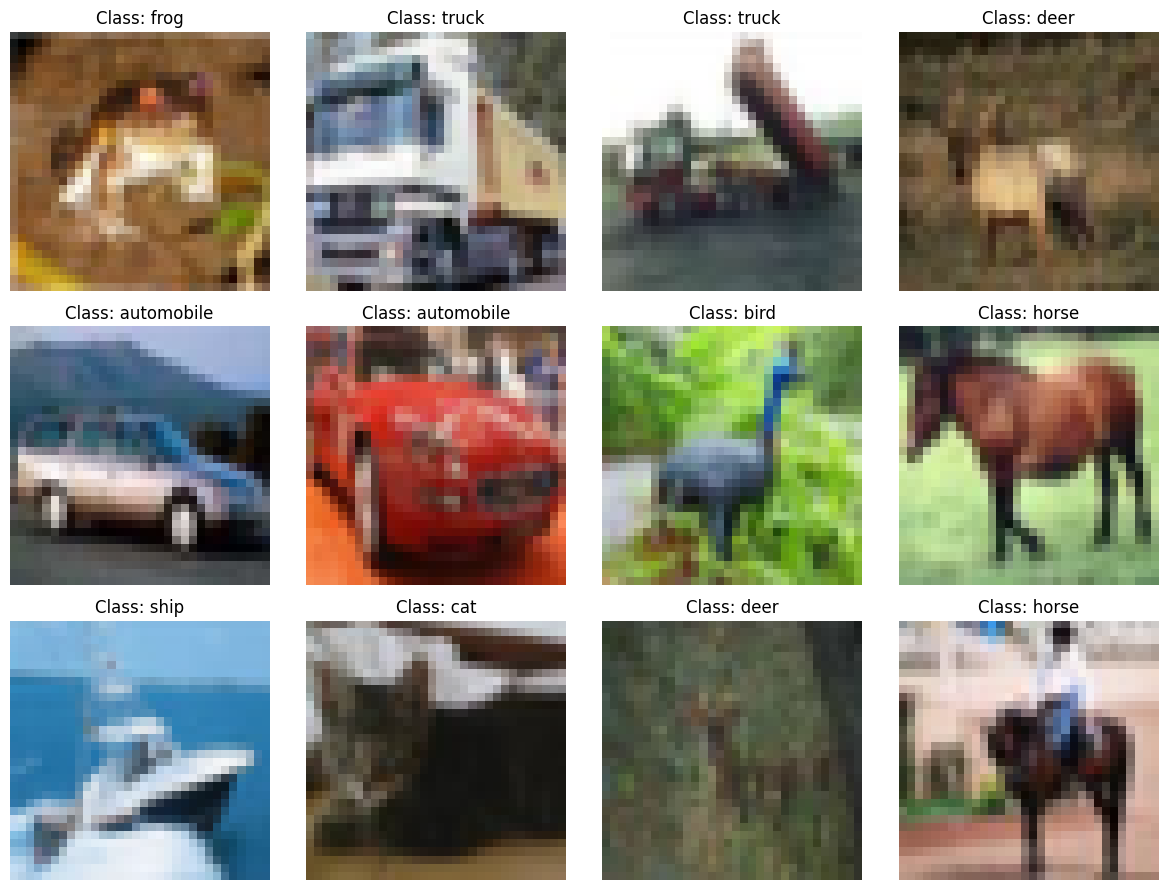


=== CLASS DISTRIBUTION ANALYSIS ===
Number of images per class in training set:
  airplane: 5000 images
  automobile: 5000 images
  bird: 5000 images
  cat: 5000 images
  deer: 5000 images
  dog: 5000 images
  frog: 5000 images
  horse: 5000 images
  ship: 5000 images
  truck: 5000 images


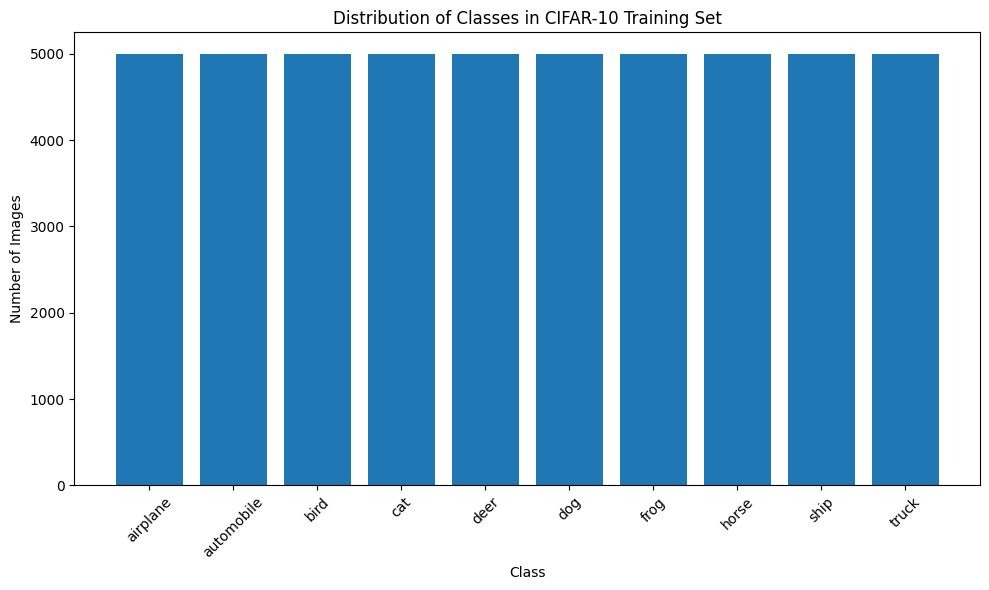

In [5]:
# Display sample images from our training set
print(f"\n=== SAMPLE IMAGES FROM CIFAR-10 ===")
print("Let's look at some examples of what our CNN will learn to classify:")
display_sample_images(x_train, y_train, class_names, num_samples=12)

# Analyze the distribution of classes in our dataset
print(f"\n=== CLASS DISTRIBUTION ANALYSIS ===")
unique_classes, class_counts = np.unique(y_train, return_counts=True)

print("Number of images per class in training set:")
for class_id, count in zip(unique_classes, class_counts):
    print(f"  {class_names[class_id]}: {count} images")

# Visualize class distribution
plt.figure(figsize=(10, 6))
plt.bar(range(len(class_names)), class_counts)
plt.title('Distribution of Classes in CIFAR-10 Training Set')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.tight_layout()
plt.show()


In [6]:
print("=== DATA PREPROCESSING ===")
print("Before feeding images to our CNN, we need to prepare them properly")
print("Think of this as cleaning and organizing photos before putting them in an album\n")

# Normalize pixel values to the range [0, 1]
# Why do this? Neural networks work better with smaller numbers
# Original pixel values are 0-255, but we'll convert them to 0.0-1.0
print("Step 1: Normalizing pixel values...")
print(f"Before normalization: pixel range is {x_train.min()} to {x_train.max()}")

x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

print(f"After normalization: pixel range is {x_train_normalized.min():.1f} to {x_train_normalized.max():.1f}")
print("This helps our neural network learn more efficiently!")

# Convert labels to categorical format (one-hot encoding)
# Why? Our CNN will output probabilities for each class
# We need labels in the same format to calculate loss properly
print(f"\nStep 2: Converting labels to categorical format...")
print(f"Before: label shape is {y_train.shape}, sample labels: {y_train[:5].flatten()}")

y_train_categorical = keras.utils.to_categorical(y_train, 10)
y_test_categorical = keras.utils.to_categorical(y_test, 10)

print(f"After: label shape is {y_train_categorical.shape}")
print(f"Sample categorical label for class {y_train[0][0]}:")
print(f"  {y_train_categorical[0]}")
print("Now each label is a vector with 1.0 for the correct class and 0.0 for others!")

# Create a smaller subset for faster training (optional)
# This is helpful for learning and experimentation
# In real projects, you'd typically use the full dataset
print(f"\nStep 3: Creating a manageable subset for learning...")
subset_size = 5000  # Use 5000 images for training, 1000 for testing

# Randomly select samples while maintaining class balance
def create_balanced_subset(x_data, y_data, subset_size, num_classes=10):
    """
    Create a balanced subset of the dataset

    This ensures we have equal representation from each class
    Think of it as carefully selecting representative photos from each category
    """
    samples_per_class = subset_size // num_classes

    x_subset = []
    y_subset = []

    for class_id in range(num_classes):
        # Find all indices for this class
        class_indices = np.where(y_data.flatten() == class_id)[0]

        # Randomly select samples from this class
        selected_indices = np.random.choice(class_indices, samples_per_class, replace=False)

        x_subset.append(x_data[selected_indices])
        y_subset.append(y_data[selected_indices])

    # Combine all classes
    x_subset = np.vstack(x_subset)
    y_subset = np.vstack(y_subset)

    # Shuffle the combined dataset
    shuffle_indices = np.random.permutation(len(x_subset))
    x_subset = x_subset[shuffle_indices]
    y_subset = y_subset[shuffle_indices]

    return x_subset, y_subset

# Create balanced subsets
x_train_subset, y_train_subset = create_balanced_subset(x_train_normalized, y_train, subset_size)
x_test_subset, y_test_subset = create_balanced_subset(x_test_normalized, y_test, 1000)

# Convert subset labels to categorical
y_train_subset_cat = keras.utils.to_categorical(y_train_subset, 10)
y_test_subset_cat = keras.utils.to_categorical(y_test_subset, 10)

print(f"Training subset: {x_train_subset.shape[0]} images")
print(f"Test subset: {x_test_subset.shape[0]} images")
print("Data preprocessing complete!")


=== DATA PREPROCESSING ===
Before feeding images to our CNN, we need to prepare them properly
Think of this as cleaning and organizing photos before putting them in an album

Step 1: Normalizing pixel values...
Before normalization: pixel range is 0 to 255
After normalization: pixel range is 0.0 to 1.0
This helps our neural network learn more efficiently!

Step 2: Converting labels to categorical format...
Before: label shape is (50000, 1), sample labels: [6 9 9 4 1]
After: label shape is (50000, 10)
Sample categorical label for class 6:
  [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
Now each label is a vector with 1.0 for the correct class and 0.0 for others!

Step 3: Creating a manageable subset for learning...
Training subset: 5000 images
Test subset: 1000 images
Data preprocessing complete!


In [7]:
print("=== BUILDING OUR CNN ARCHITECTURE ===")
print("Now we'll construct our Convolutional Neural Network step by step")
print("Think of this as designing the blueprint for our pattern recognition system\n")

def create_simple_cnn():
    """
    Create a simple but effective CNN for CIFAR-10 classification

    This function builds our neural network layer by layer
    Each layer has a specific purpose in learning to recognize image features

    Returns:
    A compiled Keras model ready for training
    """

    print("Building CNN architecture...")

    # Start with a Sequential model - layers are stacked one after another
    model = keras.Sequential([

        # Input layer - defines the shape of images we'll process
        # 32x32 pixels with 3 color channels (Red, Green, Blue)
        keras.Input(shape=(32, 32, 3)),

        # First Convolutional Block
        # Think of this as the "edge detector" - it finds basic patterns like lines and curves
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1'),
        layers.BatchNormalization(name='bn1'),  # Helps training stability
        layers.MaxPooling2D((2, 2), name='pool1'),  # Reduces image size, keeps important features

        # Second Convolutional Block
        # This layer finds more complex patterns by combining the basic patterns from layer 1
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
        layers.BatchNormalization(name='bn2'),
        layers.MaxPooling2D((2, 2), name='pool2'),

        # Third Convolutional Block
        # Even more complex patterns - might recognize shapes like wheels, wings, etc.
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),
        layers.BatchNormalization(name='bn3'),
        layers.MaxPooling2D((2, 2), name='pool3'),

        # Flatten the 2D feature maps into 1D for the dense layers
        # Think of this as laying out all the detected features in a single line
        layers.Flatten(name='flatten'),

        # Dense (Fully Connected) layers for final classification
        # These layers combine all the features to make the final decision
        layers.Dense(128, activation='relu', name='dense1'),
        layers.Dropout(0.5, name='dropout1'),  # Prevents overfitting

        layers.Dense(64, activation='relu', name='dense2'),
        layers.Dropout(0.3, name='dropout2'),

        # Output layer - one neuron for each of our 10 classes
        # Softmax activation gives us probabilities for each class
        layers.Dense(10, activation='softmax', name='output')
    ])

    return model


=== BUILDING OUR CNN ARCHITECTURE ===
Now we'll construct our Convolutional Neural Network step by step
Think of this as designing the blueprint for our pattern recognition system



In [8]:
# Create our CNN model
model = create_simple_cnn()

# Display the model architecture
print("=== CNN ARCHITECTURE SUMMARY ===")
model.summary()

# Let's understand what each layer does
print("\n=== UNDERSTANDING EACH LAYER ===")
layer_explanations = {
    'conv1': 'Detects basic features like edges and simple patterns (32 filters)',
    'bn1': 'Normalizes layer inputs to improve training stability',
    'pool1': 'Reduces spatial dimensions while keeping important features',
    'conv2': 'Detects more complex patterns by combining basic features (64 filters)',
    'bn2': 'Another normalization layer for stable training',
    'pool2': 'Further reduces dimensions, focuses on most important features',
    'conv3': 'Detects high-level features like object parts (128 filters)',
    'bn3': 'Final normalization before flattening',
    'pool3': 'Final spatial reduction',
    'flatten': 'Converts 2D feature maps to 1D vector for classification',
    'dense1': 'Combines features to understand complex patterns (128 neurons)',
    'dropout1': 'Randomly ignores some neurons to prevent overfitting',
    'dense2': 'Further processes combined features (64 neurons)',
    'dropout2': 'Additional regularization',
    'output': 'Final classification layer (10 neurons for 10 classes)'
}

for layer in model.layers:
    layer_name = layer.name
    if layer_name in layer_explanations:
        print(f"{layer_name:10}: {layer_explanations[layer_name]}")

# Calculate total parameters
total_params = model.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")
print("These are the 'knobs' our CNN will adjust during training to learn patterns!")


Building CNN architecture...
=== CNN ARCHITECTURE SUMMARY ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,322 (1.39 MB)

 Trainable params: 364,874 (1.39 MB)

 Non-trainable params: 448 (1.75 KB)


=== UNDERSTANDING EACH LAYER ===
conv1     : Detects basic features like edges and simple patterns (32 filters)
bn1       : Normalizes layer inputs to improve training stability
pool1     : Reduces spatial dimensions while keeping important features
conv2     : Detects more complex patterns by combining basic features (64 filters)
bn2       : Another normalization layer for stable training
pool2     : Further reduces dimensions, focuses on most important features
conv3     : Detects high-level features like object parts (128 filters)
bn3       : Final normalization before flattening
pool3     : Final spatial reduction
flatten   : Converts 2D feature maps to 1D vector for classification
dense1    : Combines features to understand complex patterns (128 neurons)
dropout1  : Randomly ignores some neurons to prevent overfitting
dense2    : Further processes combined features (64 neurons)
dropout2  : Additional regularization
output    : Final classification layer (10 neurons for 10 classes

In [9]:
print("=== COMPILING THE MODEL ===")
print("Now we need to configure our CNN for training")
print("This is like setting up the learning rules and success metrics\n")

# Compile the model with optimizer, loss function, and metrics
model.compile(
    # Optimizer: Algorithm that adjusts the model's parameters during training
    # Adam is a popular choice that adapts the learning rate automatically
    optimizer='adam',

    # Loss function: Measures how wrong our predictions are
    # Categorical crossentropy is perfect for multi-class classification
    loss='categorical_crossentropy',

    # Metrics: Additional measurements to track during training
    # Accuracy tells us what percentage of predictions are correct
    metrics=['accuracy']
)

print("Model compiled successfully!")
print("Optimizer: Adam (adaptive learning rate)")
print("Loss function: Categorical crossentropy (perfect for classification)")
print("Metrics: Accuracy (percentage of correct predictions)")

# Set up callbacks for better training
# Callbacks are functions that run during training to improve the process
print(f"\n=== SETTING UP TRAINING CALLBACKS ===")

# Early stopping: Stop training if the model stops improving
# This prevents overfitting and saves time
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Watch the validation loss
    patience=5,          # Wait 5 epochs before stopping
    restore_best_weights=True,  # Use the best weights found
    verbose=1
)

# Learning rate reduction: Lower learning rate when improvement slows
# This helps the model fine-tune its learning near the end
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',  # Watch validation loss
    factor=0.2,          # Reduce learning rate by 80%
    patience=3,          # Wait 3 epochs before reducing
    min_lr=0.0001,       # Don't go below this learning rate
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

print("Callbacks configured:")
print("- Early stopping: Prevents overfitting by stopping when validation loss stops improving")
print("- Learning rate reduction: Fine-tunes learning when progress slows down")


=== COMPILING THE MODEL ===
Now we need to configure our CNN for training
This is like setting up the learning rules and success metrics

Model compiled successfully!
Optimizer: Adam (adaptive learning rate)
Loss function: Categorical crossentropy (perfect for classification)
Metrics: Accuracy (percentage of correct predictions)

=== SETTING UP TRAINING CALLBACKS ===
Callbacks configured:
- Early stopping: Prevents overfitting by stopping when validation loss stops improving
- Learning rate reduction: Fine-tunes learning when progress slows down


In [10]:
print("=== TRAINING THE CNN ===")
print("Now comes the exciting part - teaching our CNN to recognize images!")
print("This is where the model learns patterns by looking at thousands of examples\n")

# Training parameters
EPOCHS = 20          # Maximum number of complete passes through the data
BATCH_SIZE = 32      # Number of images processed together (memory efficiency)
VALIDATION_SPLIT = 0.2  # Use 20% of training data for validation

print(f"Training configuration:")
print(f"- Maximum epochs: {EPOCHS}")
print(f"- Batch size: {BATCH_SIZE} (processes {BATCH_SIZE} images at once)")
print(f"- Validation split: {VALIDATION_SPLIT:.0%} (monitors overfitting)")
print(f"- Total training images: {len(x_train_subset)}")
print(f"- Images per epoch: {len(x_train_subset) * (1 - VALIDATION_SPLIT):.0f}")

print(f"\nStarting training... This may take a few minutes.")
print("Watch the accuracy increase and loss decrease as the model learns!")

# Train the model
# This is where the magic happens - the CNN learns to recognize patterns
history = model.fit(
    x_train_subset, y_train_subset_cat,  # Training data and labels
    batch_size=BATCH_SIZE,               # How many images to process at once
    epochs=EPOCHS,                       # Maximum number of training rounds
    validation_split=VALIDATION_SPLIT,   # Reserve some data for validation
    callbacks=callbacks,                 # Use our early stopping and learning rate reduction
    verbose=1                           # Show progress during training
)

print(f"\nTraining completed!")
print("The model has learned to recognize patterns in the images!")


=== TRAINING THE CNN ===
Now comes the exciting part - teaching our CNN to recognize images!
This is where the model learns patterns by looking at thousands of examples

Training configuration:
- Maximum epochs: 20
- Batch size: 32 (processes 32 images at once)
- Validation split: 20% (monitors overfitting)
- Total training images: 5000
- Images per epoch: 4000

Starting training... This may take a few minutes.
Watch the accuracy increase and loss decrease as the model learns!
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - accuracy: 0.1576 - loss: 2.6218 - val_accuracy: 0.0960 - val_loss: 4.4239 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 113ms/step - accuracy: 0.2628 - loss: 2.0447 - val_accuracy: 0.1040 - val_loss: 3.1918 - learning_rate: 0.0010
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 117ms/step - accuracy: 0.3018 - loss: 1.9134 - val_accuracy: 0.2160 - val_loss: 2.3294 - learning_rate: 0.0010
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/ste

=== ANALYZING TRAINING PROGRESS ===
Let's examine how well our CNN learned during training
These charts show the learning journey of our model



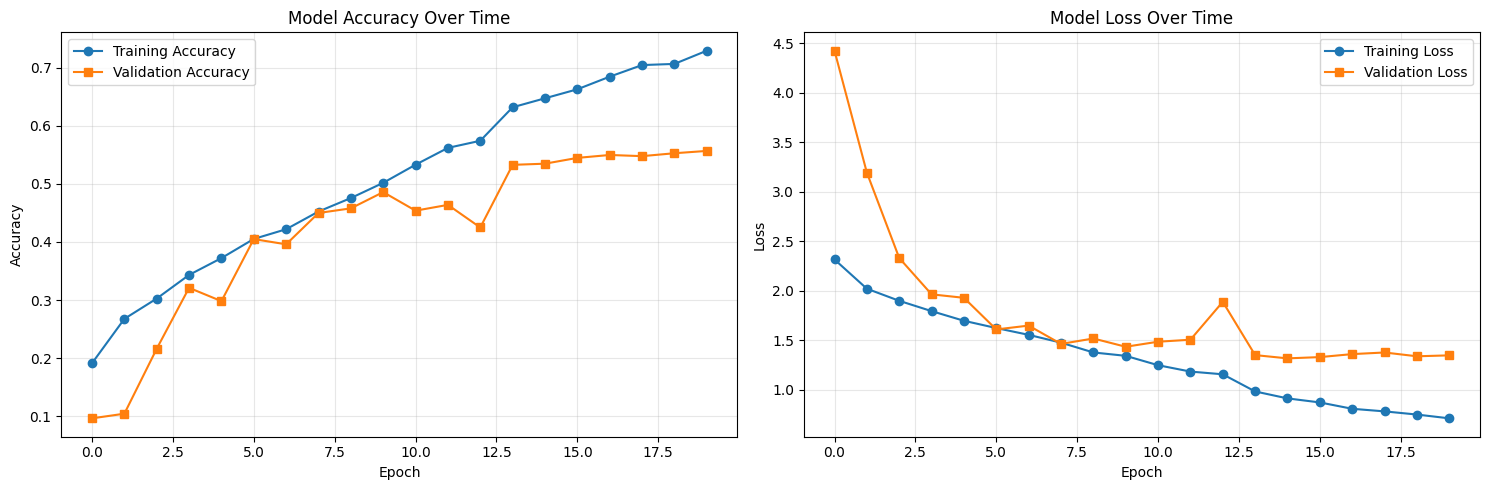

Final Training Results:
- Training Accuracy: 0.7297 (72.97%)
- Validation Accuracy: 0.5570 (55.70%)
- Training Loss: 0.7095
- Validation Loss: 1.3458

⚠️  Potential overfitting detected!
   Training accuracy is 17.3% higher than validation
   Consider more regularization or more training data


In [11]:
print("=== ANALYZING TRAINING PROGRESS ===")
print("Let's examine how well our CNN learned during training")
print("These charts show the learning journey of our model\n")

def plot_training_history(history):
    """
    Create visualizations of the training process

    This function helps us understand how the model learned over time
    Think of it as creating a report card for our CNN's learning progress
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot training and validation accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
    ax1.set_title('Model Accuracy Over Time')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot training and validation loss
    ax2.plot(history.history['loss'], label='Training Loss', marker='o')
    ax2.plot(history.history['val_loss'], label='Validation Loss', marker='s')
    ax2.set_title('Model Loss Over Time')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print final training statistics
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]

    print(f"Final Training Results:")
    print(f"- Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
    print(f"- Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
    print(f"- Training Loss: {final_train_loss:.4f}")
    print(f"- Validation Loss: {final_val_loss:.4f}")

    # Check for overfitting
    overfitting_gap = final_train_acc - final_val_acc
    if overfitting_gap > 0.1:
        print(f"\n⚠️  Potential overfitting detected!")
        print(f"   Training accuracy is {overfitting_gap*100:.1f}% higher than validation")
        print(f"   Consider more regularization or more training data")
    else:
        print(f"\n✅ Good generalization! Training and validation accuracies are close")

# Plot the training history
plot_training_history(history)


=== EVALUATING MODEL PERFORMANCE ===
Now let's test our trained CNN on completely unseen images
This tells us how well it will perform in the real world

Testing the model on unseen data...
Test Results:
- Test Accuracy: 0.5730 (57.30%)
- Test Loss: 1.1958

Generating predictions for detailed analysis...

=== PER-CLASS PERFORMANCE ===
How well does our CNN recognize each type of object?
airplane    : 0.680 (68.0%)
automobile  : 0.810 (81.0%)
bird        : 0.320 (32.0%)
cat         : 0.330 (33.0%)
deer        : 0.600 (60.0%)
dog         : 0.460 (46.0%)
frog        : 0.700 (70.0%)
horse       : 0.640 (64.0%)
ship        : 0.810 (81.0%)
truck       : 0.380 (38.0%)

=== CONFUSION MATRIX ===
This shows which classes the model confuses with each other


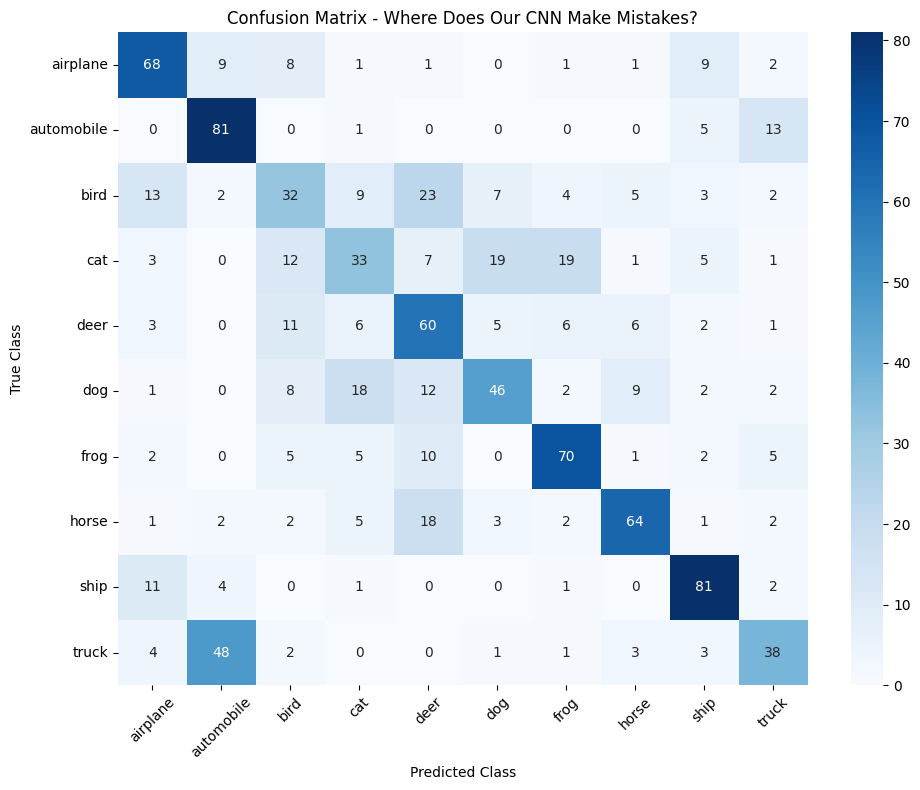

In [12]:
print("=== EVALUATING MODEL PERFORMANCE ===")
print("Now let's test our trained CNN on completely unseen images")
print("This tells us how well it will perform in the real world\n")

# Evaluate on test set
print("Testing the model on unseen data...")
test_loss, test_accuracy = model.evaluate(x_test_subset, y_test_subset_cat, verbose=0)

print(f"Test Results:")
print(f"- Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"- Test Loss: {test_loss:.4f}")

# Make predictions on test set for detailed analysis
print(f"\nGenerating predictions for detailed analysis...")
test_predictions = model.predict(x_test_subset, verbose=0)

# Convert predictions and true labels to class numbers
predicted_classes = np.argmax(test_predictions, axis=1)
true_classes = np.argmax(y_test_subset_cat, axis=1)

# Calculate per-class accuracy
print(f"\n=== PER-CLASS PERFORMANCE ===")
print("How well does our CNN recognize each type of object?")

for class_id in range(10):
    # Find all test samples of this class
    class_mask = (true_classes == class_id)
    class_predictions = predicted_classes[class_mask]
    class_accuracy = np.mean(class_predictions == class_id)

    print(f"{class_names[class_id]:12}: {class_accuracy:.3f} ({class_accuracy*100:.1f}%)")

# Create confusion matrix for detailed analysis
print(f"\n=== CONFUSION MATRIX ===")
print("This shows which classes the model confuses with each other")

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Where Does Our CNN Make Mistakes?')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [13]:
print(f"Analyzing common classification mistakes...")
mistakes = []
for i in range(10):
    for j in range(10):
        if i != j and cm[i][j] > 0:
            mistakes.append((cm[i][j], class_names[i], class_names[j]))

mistakes.sort(reverse=True)
print(f"\nMost common mistakes (True Class → Predicted Class):")
for count, true_class, pred_class in mistakes[:5]:
    print(f"  {true_class} → {pred_class}: {count} times")


Analyzing common classification mistakes...

Most common mistakes (True Class → Predicted Class):
  truck → automobile: 48 times
  bird → deer: 23 times
  cat → frog: 19 times
  cat → dog: 19 times
  horse → deer: 18 times


In [14]:
print("=== TESTING INDIVIDUAL PREDICTIONS ===")
print("Let's see how our CNN makes decisions on specific images")
print("This helps us understand what the model has learned\n")

def show_prediction_examples(model, x_test, y_test, class_names, num_examples=8):
    """
    Display individual predictions with confidence scores

    This function helps us see the model's decision-making process
    Think of it as looking over the shoulder of our CNN as it makes decisions
    """

    # Get a random sample of test images
    indices = np.random.choice(len(x_test), num_examples, replace=False)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    for i, idx in enumerate(indices):
        # Get the image and true label
        image = x_test[idx]
        true_label = np.argmax(y_test[idx])

        # Make prediction
        prediction = model.predict(np.expand_dims(image, axis=0), verbose=0)[0]
        predicted_class = np.argmax(prediction)
        confidence = prediction[predicted_class]

        # Display the image
        axes[i].imshow(image)

        # Create title with prediction information
        title_color = 'green' if predicted_class == true_label else 'red'
        title = f'True: {class_names[true_label]}\nPred: {class_names[predicted_class]}\nConf: {confidence:.3f}'
        axes[i].set_title(title, color=title_color, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    print("Color coding:")
    print("🟢 Green title: Correct prediction")
    print("🔴 Red title: Incorrect prediction")
    print("Conf: Confidence score (higher = more certain)")


=== TESTING INDIVIDUAL PREDICTIONS ===
Let's see how our CNN makes decisions on specific images
This helps us understand what the model has learned



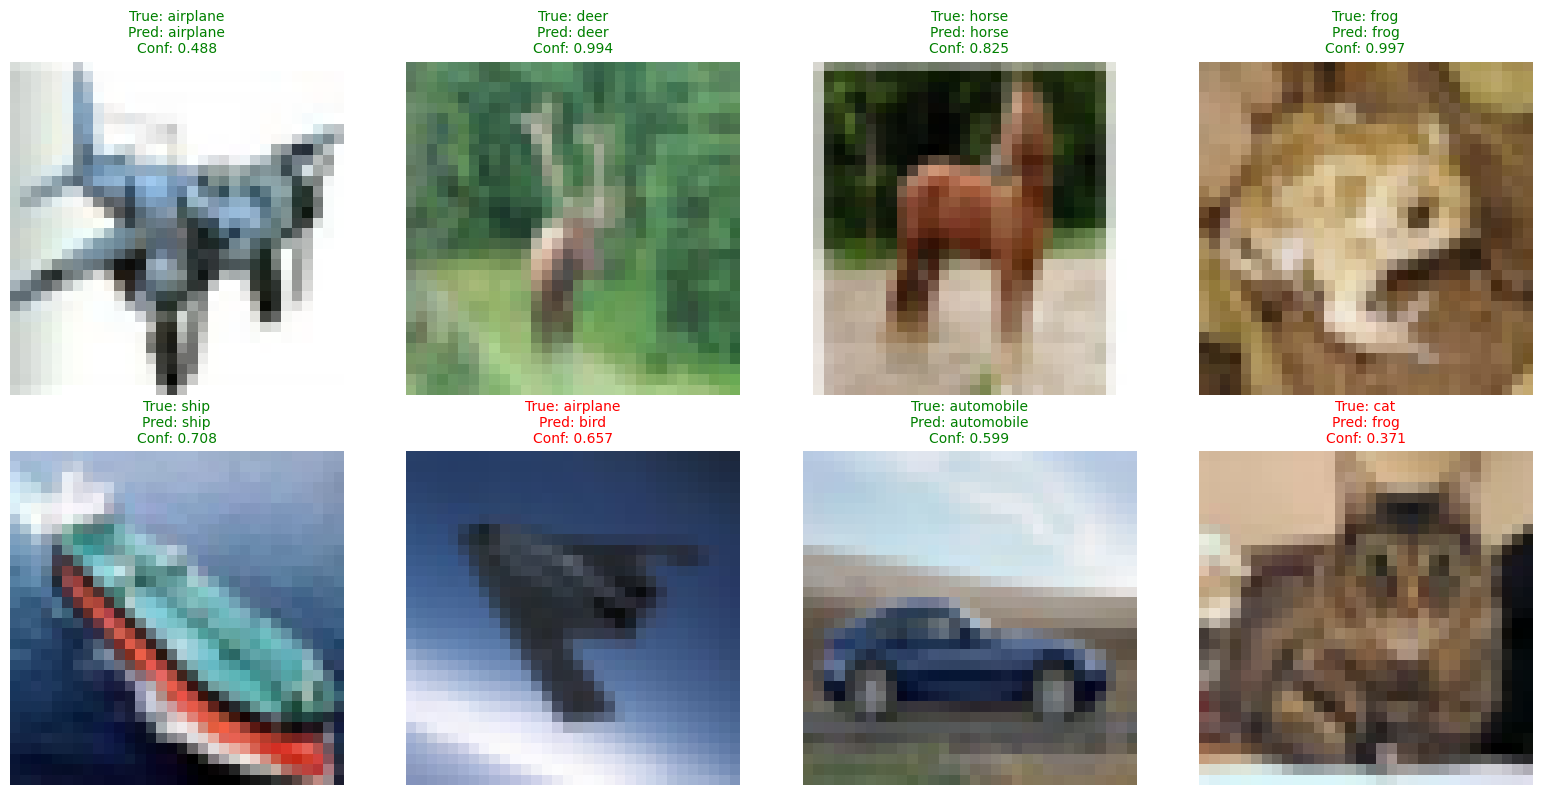

Color coding:
🟢 Green title: Correct prediction
🔴 Red title: Incorrect prediction
Conf: Confidence score (higher = more certain)


In [15]:
show_prediction_examples(model, x_test_subset, y_test_subset_cat, class_names)